
<div style="background-color: #09090B; padding: 30px; border-radius: 4px; border-left: 10px solid #FA520F; color: white; font-family: sans-serif;">
    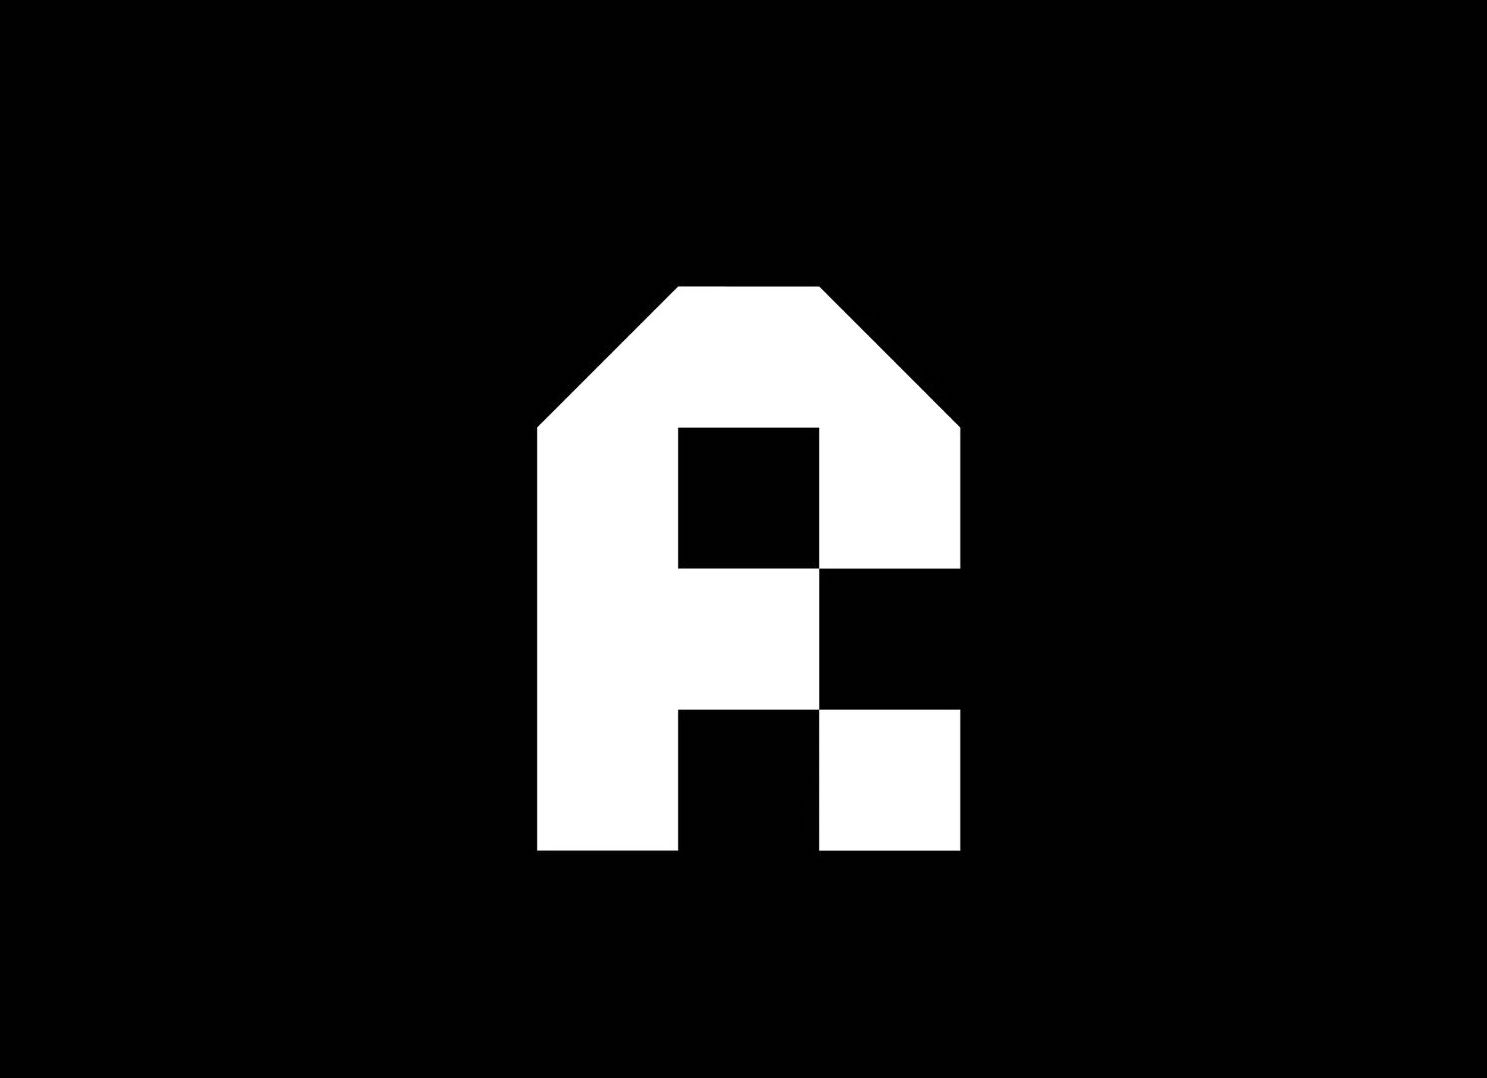
    <h1 style="color: white; margin: 10px 0 0 0; font-size: 28px;">NECTA FTNA 2020 Analysis</h1>
    <p style="color: #A1A1AA; margin: 5px 0 0 0; font-size: 14px;">Analysis of Tanzania Form Two National Assessment results.</p>
</div>



### 1. Setup
Load libraries for education data analysis.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta

# Set global style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
ANTERA_ORANGE = '#FA520F'
df_raw = pd.read_csv('ftna_2020.csv', encoding='utf-8', encoding_errors='ignore')

/var/folders/5v/755fjtcs2yqc9r4fbzwgc4hr0000gn/T/ipykernel_34807/1996459225.py:12: DtypeWarning: Columns (1,2,3,12,13,14,18,23,24,26,27,29,30,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('ftna_2020.csv', encoding='utf-8', encoding_errors='ignore')


### 2. Load Data
Load the NECTA FTNA 2020 results.

### 3. Clean Data
Standardize column names and grades.


In [54]:

df_raw.head()

,ENGL,ELECTENG,AGRI,FART,PHY,COMM,GEO,REPEATER,BIO,B/MATH,...,MUSIC,TEXTILE,COMPSTUD,TECHDRAWING,PHYEDU,B/KEEPING,HIST,CIVILENG,ENGSC,ARABIC
0,A,NaN,NaN,NaN,C,B,D,NaN,A,C,...,NaN,NaN,NaN,NaN,NaN,B,C,NaN,NaN,NaN
1,B,NaN,NaN,NaN,F,D,F,NaN,C,F,...,NaN,NaN,NaN,NaN,NaN,D,D,NaN,NaN,NaN
2,A,NaN,NaN,NaN,A,B,C,NaN,A,B,...,NaN,NaN,C,NaN,NaN,B,A,NaN,NaN,NaN
3,A,NaN,NaN,NaN,C,C,C,NaN,B,C,...,NaN,NaN,NaN,NaN,NaN,D,C,NaN,NaN,NaN
4,A,NaN,NaN,NaN,A,A,C,NaN,A,A,...,NaN,NaN,NaN,NaN,NaN,B,A,NaN,NaN,NaN


In [56]:
df_raw = pd.read_csv('ftna_2020.csv', encoding='utf-8', encoding_errors='ignore')
df_raw.tail()

/var/folders/5v/755fjtcs2yqc9r4fbzwgc4hr0000gn/T/ipykernel_34807/1789048113.py:1: DtypeWarning: Columns (1,2,3,12,13,14,18,23,24,26,27,29,30,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('ftna_2020.csv', encoding='utf-8', encoding_errors='ignore')


,ENGL,ELECTENG,AGRI,FART,PHY,COMM,GEO,REPEATER,BIO,B/MATH,...,MUSIC,TEXTILE,COMPSTUD,TECHDRAWING,PHYEDU,B/KEEPING,HIST,CIVILENG,ENGSC,ARABIC
601812,C,NaN,NaN,NaN,F,NaN,F,NaN,F,F,...,NaN,NaN,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN
601813,D,NaN,NaN,NaN,F,NaN,F,NaN,F,F,...,NaN,NaN,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN
601814,D,NaN,NaN,NaN,F,NaN,F,NaN,F,F,...,NaN,NaN,NaN,NaN,NaN,NaN,D,NaN,NaN,NaN
601815,F,NaN,NaN,NaN,F,NaN,F,NaN,F,F,...,NaN,NaN,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN
601816,F,NaN,NaN,NaN,F,NaN,F,NaN,F,F,...,NaN,NaN,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN


### 3. Clean Data
Standardize column names and grades.


In [58]:
df = df_raw.copy()
df.columns = [c.lower() for c in df.columns]
def is_pass(div): return 1 if div in ['I', 'II', 'III', 'IV'] else 0
df['pass'] = df['division'].apply(is_pass)
df.head()


,engl,electeng,agri,fart,phy,comm,geo,repeater,bio,b/math,...,textile,compstud,techdrawing,phyedu,b/keeping,hist,civileng,engsc,arabic,pass
0,A,NaN,NaN,NaN,C,B,D,NaN,A,C,...,NaN,NaN,NaN,NaN,B,C,NaN,NaN,NaN,1
1,B,NaN,NaN,NaN,F,D,F,NaN,C,F,...,NaN,NaN,NaN,NaN,D,D,NaN,NaN,NaN,1
2,A,NaN,NaN,NaN,A,B,C,NaN,A,B,...,NaN,C,NaN,NaN,B,A,NaN,NaN,NaN,1
3,A,NaN,NaN,NaN,C,C,C,NaN,B,C,...,NaN,NaN,NaN,NaN,D,C,NaN,NaN,NaN,1
4,A,NaN,NaN,NaN,A,A,C,NaN,A,A,...,NaN,NaN,NaN,NaN,B,A,NaN,NaN,NaN,1


### 4. Performance Analysis
Compare pass rates by gender.


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601817 entries, 0 to 601816
Data columns (total 37 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   engl               601313 non-null  object 
 1   electeng           587 non-null     object 
 2   agri               22073 non-null   object 
 3   fart               837 non-null     object 
 4   phy                598289 non-null  object 
 5   comm               78969 non-null   object 
 6   geo                601134 non-null  object 
 7   repeater           14496 non-null   object 
 8   bio                601200 non-null  object 
 9   b/math             601105 non-null  object 
 10  e/d/kiislamu       82323 non-null   object 
 11  division           601817 non-null  object 
 12  t/art              355 non-null     object 
 13  fren               10799 non-null   object 
 14  chinese            1085 non-null    object 
 15  sex                601817 non-null  object 
 16  ci

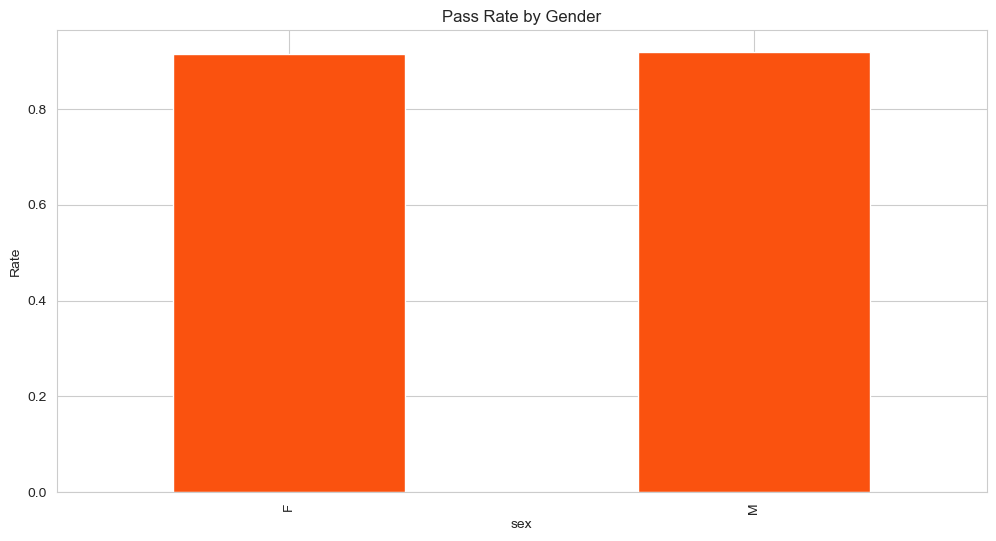

In [64]:
df.groupby('sex')['pass'].mean().plot(kind='bar', color=ANTERA_ORANGE)
plt.title('Pass Rate by Gender')
plt.ylabel('Rate')
plt.show()

### 5. Subject Analysis
Identify subjects with high failure rates.


### 6. Dashboard
Summary of key education metrics.


In [68]:
total_pass = df['pass'].mean() * 100
print(f'Overall Pass Rate: {total_pass:.2f}%')


Overall Pass Rate: 91.61%


In [73]:
# analyze grade counts
# distribution of grades for Basic Math
print(df['b/math'].value_counts(dropna=False))

# Look at the missing values (NaNs) to see subject popularity/enrollment
enrollment = df[['b/math', 'phy', 'chem', 'engl', 'kisw']].notna().mean() * 100
print("Subject Enrollment Rates (%):\n", enrollment)

b/math
F      505311
D       42258
C       31560
A       11680
B       10296
NaN       712
Name: count, dtype: int64
Subject Enrollment Rates (%):
 b/math    99.881692
phy       99.413775
chem      99.808414
engl      99.916254
kisw      99.923565
dtype: float64


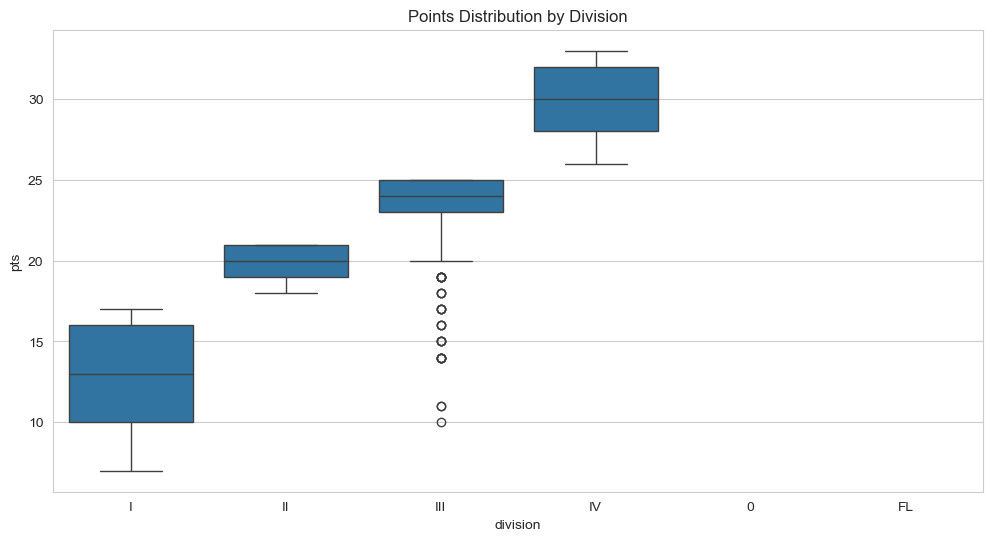

In [75]:

# Boxplot of points by Division to see the thresholds clearly
sns.boxplot(data=df, x='division', y='pts', order=['I', 'II', 'III', 'IV', '0', 'FL'])
plt.title('Points Distribution by Division')
plt.show()

Math Grade Distribution by Gender (%):
 sex             F          M
b/math                      
A        1.337049   2.650258
B        1.214404   2.294463
C        3.974692   6.738835
D        5.858547   8.397048
F       87.615308  79.919396


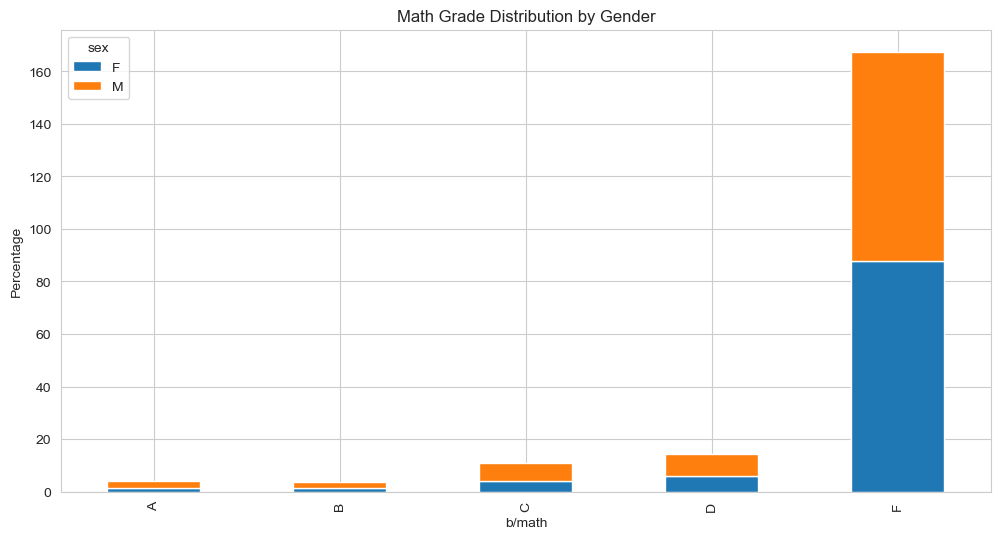

In [77]:
# cross-tabulation of Math grades by Gender
math_gender = pd.crosstab(df['b/math'], df['sex'], normalize='columns') * 100
print("Math Grade Distribution by Gender (%):\n", math_gender)

# Plot it
math_gender.plot(kind='bar', stacked=True)
plt.title('Math Grade Distribution by Gender')
plt.ylabel('Percentage')
plt.show()

## Predictive Modeling (Machine Learning)

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# features based on whether they took specific elective subjects (1 if took it, 0 if NaN)
features = df[['agri', 'comm', 'b/keeping', 'compstud']].notna().astype(int)

X = features
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Check which elective subjects correlate most with passing
for feature, importance in zip(X.columns, model.feature_importances_):
    print(f"{feature}: {importance:.4f}")

agri: 0.0578
comm: 0.2441
b/keeping: 0.4887
compstud: 0.2094


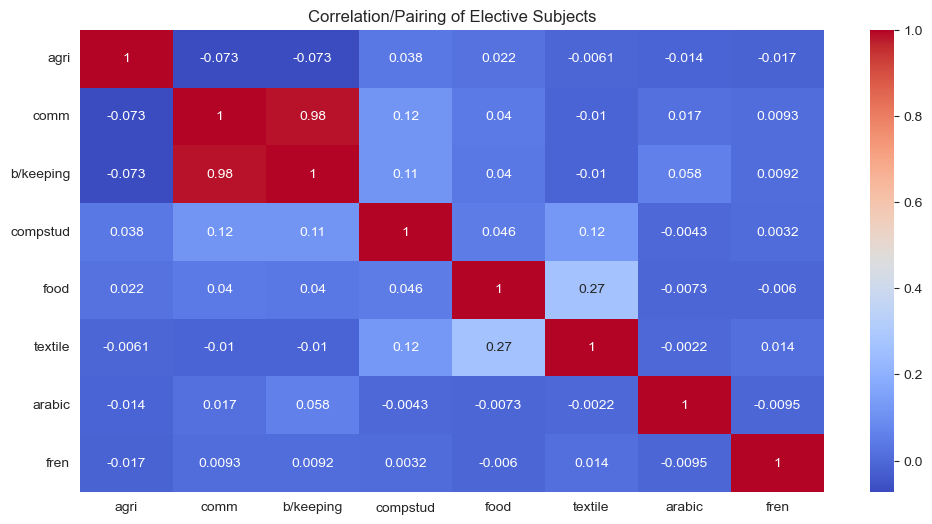

In [89]:
#columns that are purely elective subjects
electives = df[['agri', 'comm', 'b/keeping', 'compstud', 'food', 'textile', 'arabic', 'fren']]

# Create a boolean matrix of who took what
elective_matrix = electives.notna().astype(int)

# Calculate correlation matrix
correlation_matrix = elective_matrix.corr()

import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation/Pairing of Elective Subjects')
plt.show()

In [91]:
# Filter for Division I candidates
top_performers = df[df['division'] == 'I']

# Compare the gender distribution of top performers vs the entire dataset
print("Overall Gender Distribution:\n", df['sex'].value_counts(normalize=True))
print("\nTop Performers Gender Distribution:\n", top_performers['sex'].value_counts(normalize=True))

Overall Gender Distribution:
 sex
F    0.53823
M    0.46177
Name: proportion, dtype: float64

Top Performers Gender Distribution:
 sex
M    0.57934
F    0.42066
Name: proportion, dtype: float64
